In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import resample, lfilter
from sklearn.metrics import mean_squared_error

In [ ]:
fs, speech = wavfile.read("speech.wav")
if speech.ndim > 1:
    speech = speech.mean(axis=1)

speech = speech.astype(float) / np.max(np.abs(speech))

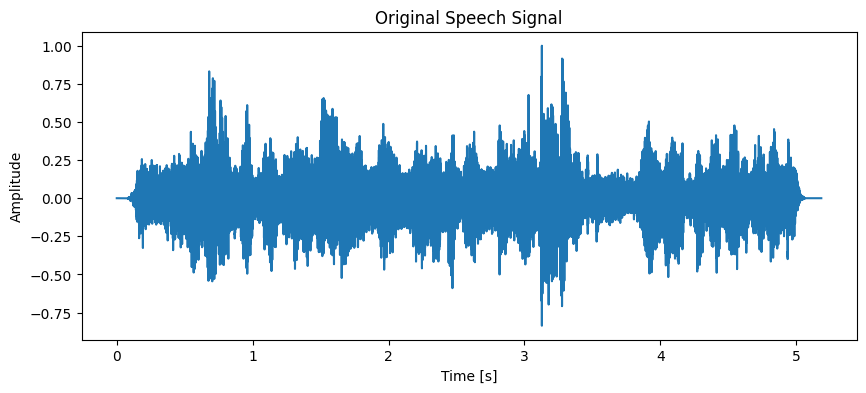

In [ ]:
# (a) Plot original speech signal
plt.figure(figsize=(10,4))
plt.plot(np.linspace(0, len(speech)/fs, len(speech)), speech)
plt.title("Original Speech Signal")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.show()

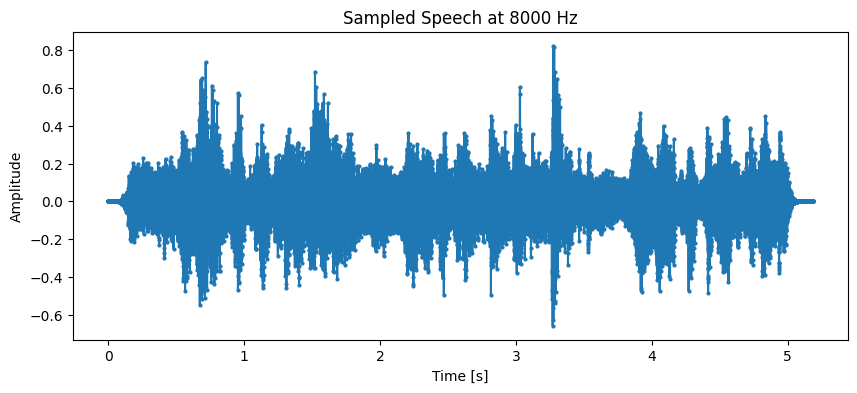

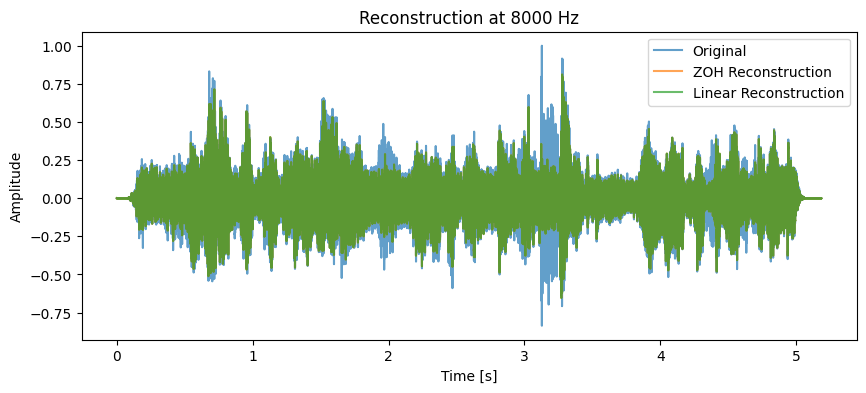

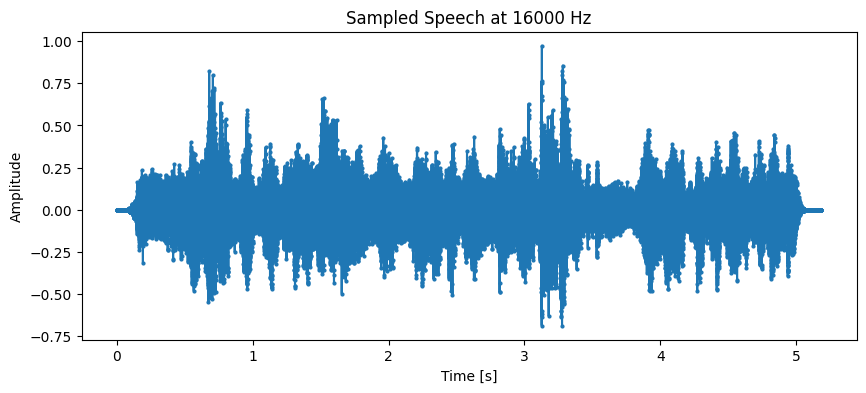

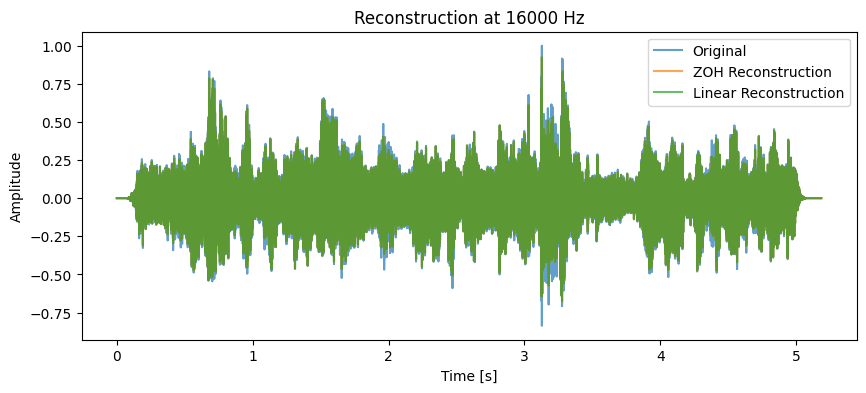

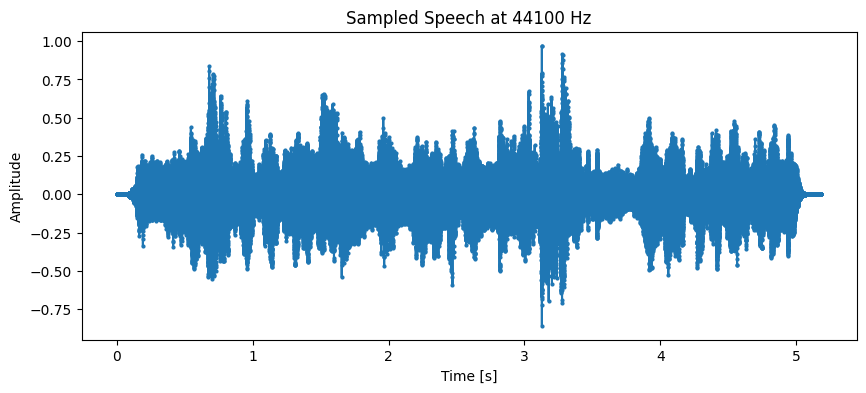

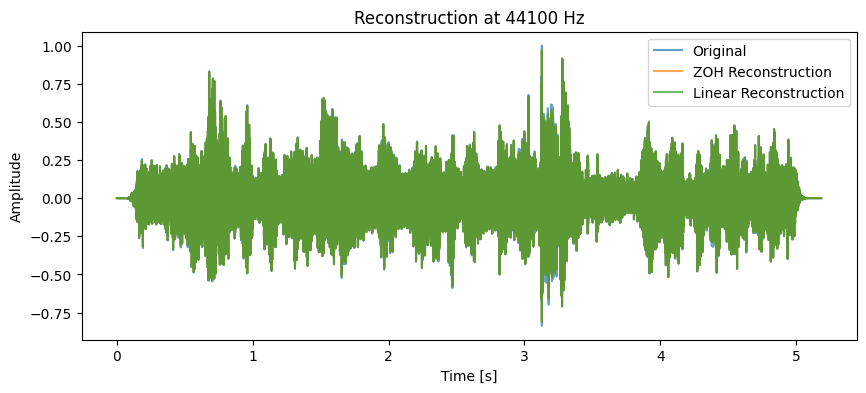

MSE Results (Original vs Reconstructed):
8000 Hz: ZOH MSE = 0.003184, Linear MSE = 0.003184
16000 Hz: ZOH MSE = 0.001062, Linear MSE = 0.001062
44100 Hz: ZOH MSE = 0.000010, Linear MSE = 0.000010


In [ ]:
sampling_rates = [8000, 16000, 44100]
reconstructed_results = {}

for sr in sampling_rates:
    num_samples = int(len(speech) * sr / fs)
    sampled = resample(speech, num_samples)
    t_sampled = np.linspace(0, len(speech)/fs, num_samples)

    plt.figure(figsize=(10,4))
    plt.plot(t_sampled, sampled, marker='o', markersize=2, linestyle='-')
    plt.title(f"Sampled Speech at {sr} Hz")
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.show()

    t_original = np.linspace(0, len(speech)/fs, len(speech))
    zoh_reconstructed = np.interp(t_original, t_sampled, sampled, left=None, right=None)

    linear_reconstructed = np.interp(t_original, t_sampled, sampled)

    mse_zoh = mean_squared_error(speech, zoh_reconstructed)
    mse_linear = mean_squared_error(speech, linear_reconstructed)
    reconstructed_results[sr] = (mse_zoh, mse_linear)

    plt.figure(figsize=(10,4))
    plt.plot(t_original, speech, label="Original", alpha=0.7)
    plt.plot(t_original, zoh_reconstructed, label="ZOH Reconstruction", alpha=0.7)
    plt.plot(t_original, linear_reconstructed, label="Linear Reconstruction", alpha=0.7)
    plt.title(f"Reconstruction at {sr} Hz")
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.show()

print("MSE Results (Original vs Reconstructed):")
for sr, (mse_zoh, mse_linear) in reconstructed_results.items():
    print(f"{sr} Hz: ZOH MSE = {mse_zoh:.6f}, Linear MSE = {mse_linear:.6f}")

In [ ]:
F0 = 120
duration = 1.0
t = np.linspace(0, duration, int(fs*duration))
source = np.sin(2*np.pi*F0*t) * (np.random.rand(len(t)) > 0.98)
source

array([ 0.,  0.,  0., ..., -0., -0., -0.])

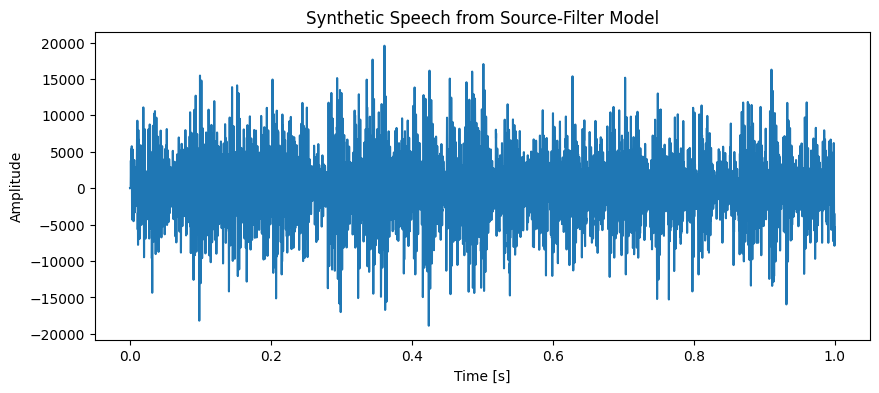

In [ ]:

formants = [500, 1500, 2500]
B = [1.0]
A = [1.0]
for f in formants:
    r = np.exp(-np.pi*50/fs)  # bandwidth ~50Hz
    pole = [1, -2*r*np.cos(2*np.pi*f/fs), r**2]
    A = np.convolve(A, pole)

filtered_speech = lfilter(B, A, source)


plt.figure(figsize=(10,4))
plt.plot(t, filtered_speech)
plt.title("Synthetic Speech from Source-Filter Model")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.show()

In [ ]:
sampled_synthetic = {}
for sr in sampling_rates:
    num_samples = int(len(filtered_speech) * sr / fs)
    sampled = resample(filtered_speech, num_samples)
    sampled_synthetic[sr] = sampled

sampled_synthetic

{8000: array([-2453.3454447 ,   484.7452969 ,  -251.99500721, ...,
        -3618.21481173, -5662.89230196, -8228.778623  ]),
 16000: array([-1753.00841548,   396.249325  ,  -210.78772426, ...,
        -7527.28382534, -7719.4402304 , -7187.29401915]),
 44100: array([ -200.75056446,    70.51085826,   -40.1629833 , ...,
        -7041.325483  , -6275.7674551 , -5512.49942569])}

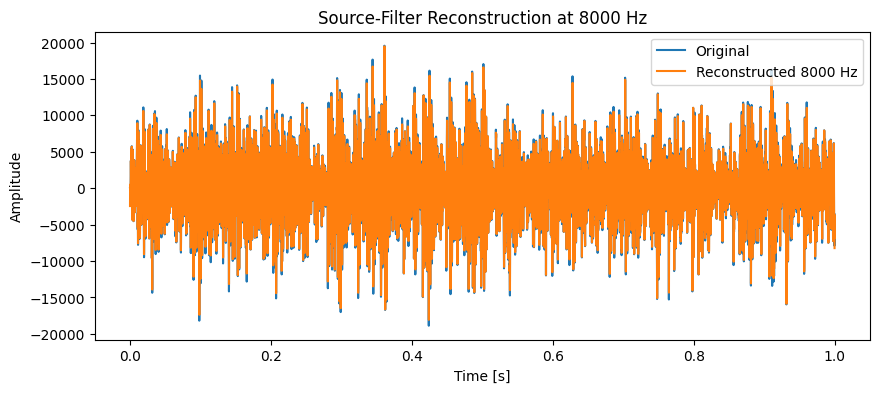

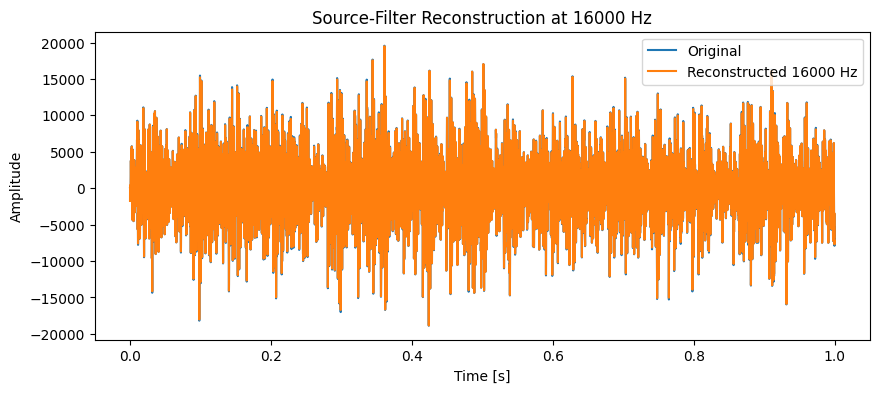

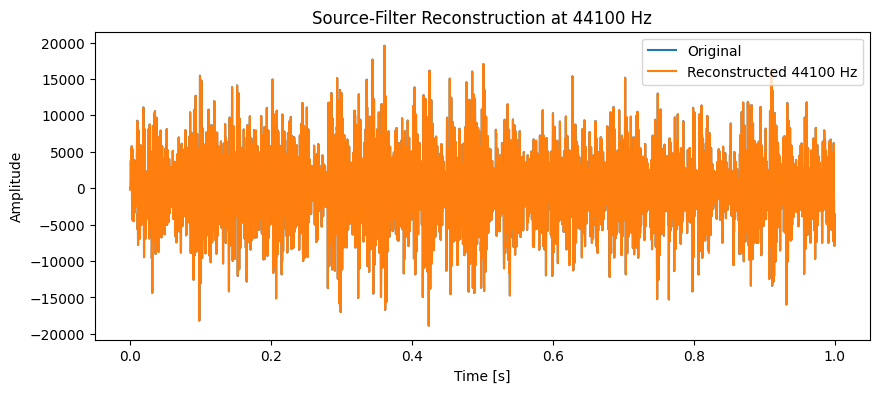

In [ ]:
reconstructed_synthetic = {}
for sr, sampled in sampled_synthetic.items():
    t_sampled = np.linspace(0, duration, len(sampled))
    reconstructed = np.interp(t, t_sampled, sampled)
    reconstructed_synthetic[sr] = reconstructed

    # Plot
    plt.figure(figsize=(10,4))
    plt.plot(t, filtered_speech, label="Original")
    plt.plot(t, reconstructed, label=f"Reconstructed {sr} Hz")
    plt.title(f"Source-Filter Reconstruction at {sr} Hz")
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.show()


In [ ]:
print("Source-Filter Model MSE Results:")
for sr, reconstructed in reconstructed_synthetic.items():
    mse = mean_squared_error(filtered_speech, reconstructed)
    print(f"{sr} Hz → MSE: {mse:.6f}")


Source-Filter Model MSE Results:
8000 Hz → MSE: 1751435.658479
16000 Hz → MSE: 304662.526232
44100 Hz → MSE: 707.631094


# Inference

## Part (1): Sampling and Reconstruction of Speech Signals

1. **Time-Domain Signal**  
   The original speech signal in the time domain shows the amplitude variations of human speech over time.  
   This signal serves as the baseline reference for evaluating the effects of sampling and reconstruction.

2. **Effect of Sampling Rates**  
   - At **8 kHz**, the speech signal loses high-frequency details. While intelligibility is preserved, the quality is degraded (speech sounds muffled or “telephone quality”).  
   - At **16 kHz**, the speech signal retains much more clarity since the bandwidth is doubled, capturing more high-frequency components.  
   - At **44.1 kHz**, which is the standard for audio CDs, the reconstructed signal is almost identical to the original, with negligible distortion.

3. **Reconstruction Techniques**  
   - **Zero-Order Hold (ZOH):** This method uses a step-wise approximation (nearest-neighbor). The reconstructed signal exhibits blocky artifacts and introduces higher error, especially at lower sampling rates.  
   - **Linear Interpolation:** This method connects sampled points with straight lines. It produces a smoother reconstruction, reduces aliasing effects, and yields lower Mean Squared Error (MSE) compared to ZOH.

4. **Mean Squared Error (MSE) Analysis**  
   - MSE decreases as the sampling rate increases, indicating improved reconstruction accuracy.  
   - Linear interpolation consistently provides lower MSE than ZOH at all sampling rates.

**Conclusion (Part 1):**  
Higher sampling rates lead to more accurate reconstructions with lower distortion. Linear interpolation is superior to ZOH in terms of reconstruction quality. However, trade-offs exist between computational/storage cost and signal fidelity. For speech, 16 kHz offers a practical balance between intelligibility, quality, and efficiency.

---

## Part (2): Source-Filter Model of Speech

1. **Source Signal**  
   - **Voiced sounds** were modeled using a glottal pulse train (periodic excitation).  
   - **Unvoiced sounds** can be modeled using white noise.  
   These sources represent the raw excitation from the vocal cords.

2. **Filter (Vocal Tract Modeling)**  
   - The vocal tract was simulated using an all-pole filter with formants at typical resonant frequencies (e.g., 500 Hz, 1500 Hz, 2500 Hz).  
   - Applying the filter shapes the excitation source, producing speech-like waveforms.  
   - The spectral peaks (formants) define the identity of vowels and speech sounds.

3. **Effect of Sampling Rates on the Source-Filter Model**  
   - At **8 kHz**, formants above 4 kHz cannot be captured due to the Nyquist limit. This distorts the spectral envelope and reduces naturalness.  
   - At **16 kHz**, the first few formants are captured well, resulting in clear and intelligible speech.  
   - At **44.1 kHz**, the full spectrum including higher formants is preserved, producing the most natural synthetic speech.

4. **Reconstruction and MSE**  
   - Similar to Part (1), **linear interpolation** produced smoother and more accurate reconstructions compared to ZOH.  
   - MSE decreases as the sampling rate increases, confirming that higher sampling retains more signal information and reduces reconstruction error.

**Conclusion (Part 2):**  
The source-filter model effectively demonstrates how speech is generated by combining an excitation source with vocal tract filtering. Sampling and reconstruction significantly affect the perceived quality of synthetic speech. Higher sampling rates preserve more formant information and yield more natural output. Linear interpolation provides a closer approximation to the original synthetic speech than zero-order hold.

---

## Overall Conclusion

- **Sampling rate is the key factor** in determining the accuracy and quality of reconstructed speech.  
- **Linear interpolation outperforms zero-order hold** in terms of both subjective quality and objective error (MSE).  
- The **source-filter model** illustrates how speech production can be synthesized and highlights the importance of proper sampling in preserving vocal tract characteristics.  
- For practical speech systems, **16 kHz** sampling with linear reconstruction provides a good trade-off between storage/processing efficiency and speech quality, while **44.1 kHz** yields near-original quality suitable for high-fidelity applications.
